# Fret-Assignment Error Analysis — where does the 31% live?

Companion to **`AudioToTabCAGED (2).ipynb`**. Test TDR (`tab_accuracy_given_pitch_match`) sits at ~0.69, so ~31% of correctly-detected notes get assigned to the wrong string/fret. This notebook localizes those errors so the fix targets the real bucket instead of guessing.

**Central reframe:** for a fixed pitch, choosing the string *uniquely determines* the fret (`fret = midi − open_string_midi[string]`). So `string_correct ⇔ fret_correct ⇔ exact_tab_correct` for every matched note — **every assignment error is a string-selection error.** The whole question is: when the algorithm picks a different string than the human, *which* string, *where* on the neck, and in *what* musical context.

It reads the `audio_to_tab_matches.csv` your pipeline already saved (all three methods, held-out test). No re-run needed.

The three decisive outputs are up top: **(1)** how many errors are adjacent-string "valid alternates" vs genuinely far off, **(2)** solo vs comp, **(3)** the predicted-vs-true string confusion matrix. Those three point directly at which lever — position prior, voicing logic, or chord-context detection — to pull.


## 1. Load matches (no pipeline re-run)

In [1]:
import pandas as pd, numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

# EDIT if your output dir differs.
AUDIO_OUTPUT_DIR = Path('/content/drive/MyDrive/Capstone/outputs/audio_to_tab_basic_pitch_heldout')
MATCHES_CSV = AUDIO_OUTPUT_DIR / 'audio_to_tab_matches.csv'
assert MATCHES_CSV.exists(), f"Not found: {MATCHES_CSV}\nRun the eval cell in AudioToTabCAGED (2).ipynb first, or fix the path."

OPEN_STRING_MIDI = [40, 45, 50, 55, 59, 64]   # E2 A2 D3 G3 B3 E4  (index 0 = low E, GuitarSet convention)
STRING_NAMES     = ['low_E','A','D','G','B','high_E']
MAX_FRET = 24

m = pd.read_csv(MATCHES_CSV)
print("Rows:", len(m), "| methods:", sorted(m['method'].dropna().unique()))

# Coerce the boolean columns (CSV may store them as strings).
def as_bool(s): return s.astype(str).str.lower().isin(['true','1','1.0'])
for c in ['exact_tab_correct','string_correct','fret_correct']:
    if c in m: m[c] = as_bool(m[c])
for c in ['pred_string','pred_fret','true_string','true_fret','midi']:
    if c in m: m[c] = pd.to_numeric(m[c], errors='coerce')
m['is_solo'] = m['recording'].astype(str).str.endswith('_solo')
m['segment'] = np.where(m['is_solo'],'solo','comp')
print("Columns:", list(m.columns))

Mounted at /content/drive
Rows: 23004 | methods: ['caged_box', 'caged_voiced', 'combined_all_tuned']
Columns: ['recording', 'pred_start', 'gt_start', 'onset_error', 'midi', 'pred_string', 'pred_fret', 'true_string', 'true_fret', 'pred_amplitude', 'exact_tab_correct', 'string_correct', 'fret_correct', 'method', 'is_solo', 'segment']


## 2. Choose method + sanity-check TDR across all three

In [2]:
METHOD = 'caged_voiced'    # 'caged_box' | 'caged_voiced' | 'combined_all_tuned'

tdr_by_method = (m.groupby('method')
                   .agg(n_matched=('exact_tab_correct','size'),
                        TDR=('exact_tab_correct','mean'),
                        string_acc=('string_correct','mean'),
                        fret_acc=('fret_correct','mean'))
                   .sort_values('TDR', ascending=False))
print("TDR by method (string_acc == fret_acc == TDR confirms the reframe):")
display(tdr_by_method.round(4))

d = m[m['method']==METHOD].dropna(subset=['pred_string','true_string']).copy()
print(f"\nAnalyzing method='{METHOD}': {len(d)} matched notes, TDR={d['exact_tab_correct'].mean():.4f}")
wrong = d[~d['exact_tab_correct']].copy()
print(f"Wrong assignments: {len(wrong)} ({len(wrong)/len(d):.1%} of matched notes)")

TDR by method (string_acc == fret_acc == TDR confirms the reframe):


,n_matched,TDR,string_acc,fret_acc
method,,,,
caged_voiced,7668,0.6918,0.6918,0.6918
caged_box,7668,0.6854,0.6854,0.6854
combined_all_tuned,7668,0.6472,0.6472,0.6472



Analyzing method='caged_voiced': 7668 matched notes, TDR=0.6918
Wrong assignments: 2363 (30.8% of matched notes)


## 3. DECISIVE #1 — How far off are the wrong ones?

If errors are overwhelmingly **adjacent-string** (|Δstring| = 1), they're *valid alternate fingerings* — the same pitch played one string over, which the human happened to finger differently. That's a fidelity-to-human problem (position-prior lever), not a "broken tab" problem. If a meaningful share are far-off (|Δstring| ≥ 2), those are genuinely wrong and point at the candidate-scoring logic.

String distance when WRONG (|pred_string - true_string|):
  1 string(s) off:  2263  (95.8%)
  2 string(s) off:    85  (3.6%)
  3 string(s) off:    14  (0.6%)
  5 string(s) off:     1  (0.0%)

Adjacent-string (±1) share of errors: 95.8%
Far-off (>=2 strings) share:           4.2%


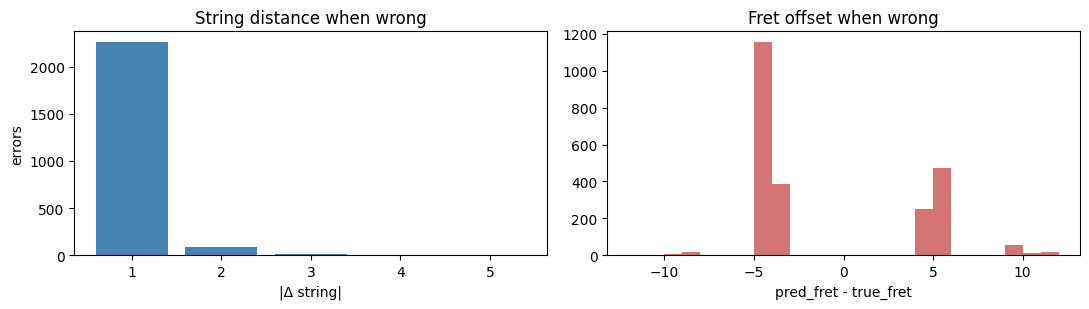

In [3]:
wrong['d_string'] = wrong['pred_string'] - wrong['true_string']   # +1 => predicted one string higher
wrong['abs_d_string'] = wrong['d_string'].abs()
wrong['d_fret'] = (wrong['pred_fret'] - wrong['true_fret'])

dist = wrong['abs_d_string'].value_counts().sort_index()
print("String distance when WRONG (|pred_string - true_string|):")
for k,v in dist.items():
    print(f"  {int(k)} string(s) off: {v:5d}  ({v/len(wrong):.1%})")
adj = (wrong['abs_d_string']==1).mean()
print(f"\nAdjacent-string (±1) share of errors: {adj:.1%}")
print(f"Far-off (>=2 strings) share:           {(wrong['abs_d_string']>=2).mean():.1%}")

fig, ax = plt.subplots(1,2, figsize=(11,3.2))
ax[0].bar(dist.index.astype(int), dist.values, color='steelblue'); ax[0].set_xlabel('|Δ string|'); ax[0].set_ylabel('errors'); ax[0].set_title('String distance when wrong')
fr = wrong['d_fret'].clip(-12,12)
ax[1].hist(fr, bins=range(-12,13), color='indianred', alpha=0.85); ax[1].set_xlabel('pred_fret - true_fret'); ax[1].set_title('Fret offset when wrong')
plt.tight_layout(); plt.show()

## 4. DECISIVE #2 — Solo vs comp

In [4]:
seg = (d.groupby('segment')
         .agg(n_matched=('exact_tab_correct','size'),
              TDR=('exact_tab_correct','mean'),
              adj_err_share=('exact_tab_correct', lambda s: np.nan))  # placeholder, filled below
      )
# adjacency within errors, per segment
rows=[]
for s,g in d.groupby('segment'):
    w=g[~g['exact_tab_correct']]
    rows.append({'segment':s,'n_matched':len(g),'TDR':g['exact_tab_correct'].mean(),
                 'n_errors':len(w),
                 'adj_err_share':(w['pred_string'].sub(w['true_string']).abs()==1).mean() if len(w) else np.nan,
                 'far_err_share':(w['pred_string'].sub(w['true_string']).abs()>=2).mean() if len(w) else np.nan})
seg_df=pd.DataFrame(rows)
print("TDR and error character by segment:")
display(seg_df.round(4))
print("If comp TDR << solo TDR, the voicing/chord-context path is the weak link.")
print("If solo TDR << comp TDR, the solo chord-context collapse (~10% chord detect) is dragging assignment.")

TDR and error character by segment:


,segment,n_matched,TDR,n_errors,adj_err_share,far_err_share
0,comp,5252,0.7308,1414,0.9788,0.0212
1,solo,2416,0.6072,949,0.9262,0.0738


If comp TDR << solo TDR, the voicing/chord-context path is the weak link.
If solo TDR << comp TDR, the solo chord-context collapse (~10% chord detect) is dragging assignment.


## 5. DECISIVE #3 — String confusion matrix

Row = string the human used, column = string the algorithm picked. Row-normalized, so the diagonal is per-string accuracy and off-diagonal shows the systematic confusions (e.g. always sliding toward higher/lower strings, or one CAGED box stealing notes from a neighbor).

Row-normalized string confusion (diagonal = per-string accuracy):


,pred_low_E,pred_A,pred_D,pred_G,pred_B,pred_high_E
true_low_E,0.694,0.302,0.003,0.000,0.000,0.000
true_A,0.040,0.741,0.217,0.002,0.000,0.000
true_D,0.003,0.050,0.701,0.242,0.003,0.000
true_G,0.004,0.003,0.082,0.699,0.205,0.006
true_B,0.000,0.002,0.008,0.169,0.626,0.194
true_high_E,0.001,0.000,0.004,0.056,0.244,0.695


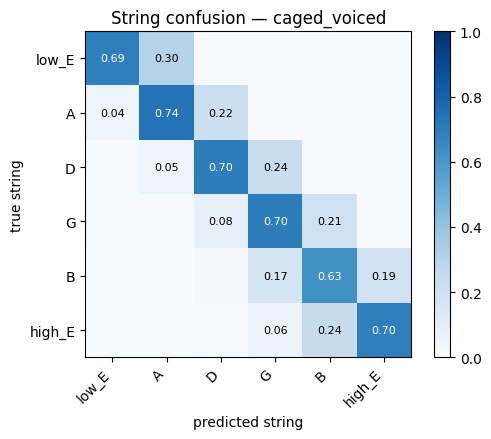

Per-string accuracy (diagonal):
  low_E  : 0.694
  A      : 0.741
  D      : 0.701
  G      : 0.699
  B      : 0.626
  high_E : 0.695


In [5]:
ct = pd.crosstab(d['true_string'].astype(int), d['pred_string'].astype(int))
ct = ct.reindex(index=range(6), columns=range(6), fill_value=0)
ctn = ct.div(ct.sum(axis=1).replace(0,np.nan), axis=0)
ctn.index = [f'true_{STRING_NAMES[i]}' for i in range(6)]
ctn.columns = [f'pred_{STRING_NAMES[i]}' for i in range(6)]
print("Row-normalized string confusion (diagonal = per-string accuracy):")
display(ctn.round(3))

fig, ax = plt.subplots(figsize=(5.5,4.5))
im=ax.imshow(ctn.values, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(6)); ax.set_xticklabels(STRING_NAMES, rotation=45, ha='right')
ax.set_yticks(range(6)); ax.set_yticklabels(STRING_NAMES)
ax.set_xlabel('predicted string'); ax.set_ylabel('true string'); ax.set_title(f'String confusion — {METHOD}')
for i in range(6):
    for j in range(6):
        v=ctn.values[i,j]
        if not np.isnan(v) and v>0.02: ax.text(j,i,f'{v:.2f}',ha='center',va='center',color='white' if v>0.5 else 'black',fontsize=8)
plt.colorbar(im,fraction=0.046); plt.tight_layout(); plt.show()

print("Per-string accuracy (diagonal):")
for i in range(6):
    acc = ctn.values[i,i]
    print(f"  {STRING_NAMES[i]:7s}: {acc:.3f}" if not np.isnan(acc) else f"  {STRING_NAMES[i]:7s}: (none)")

## 6. Where on the neck — fret region & position ambiguity

Two questions: do errors cluster high up the neck (where CAGED boxes overlap and more strings can play a note), and do they cluster on pitches with **more candidate strings** (inherently more ambiguous)? A note forced onto one string can't be mis-assigned; a mid-range note playable on 4 strings is where the choice is hard.

TDR by true fret region:


,n,TDR
true_fret_region,,
0-4,2751,0.7844
5-9,4240,0.6811
10-14,669,0.3871
15+,8,0.0000



TDR by # candidate strings for the pitch (ambiguity):


,n,TDR
n_cand,,
1,270,1.0000
2,833,0.7443
3,1283,0.7272
4,1865,0.6804
5,2997,0.6557
6,420,0.5905


Accuracy should fall as candidate strings rise — that's the disambiguation the prior is meant to solve.


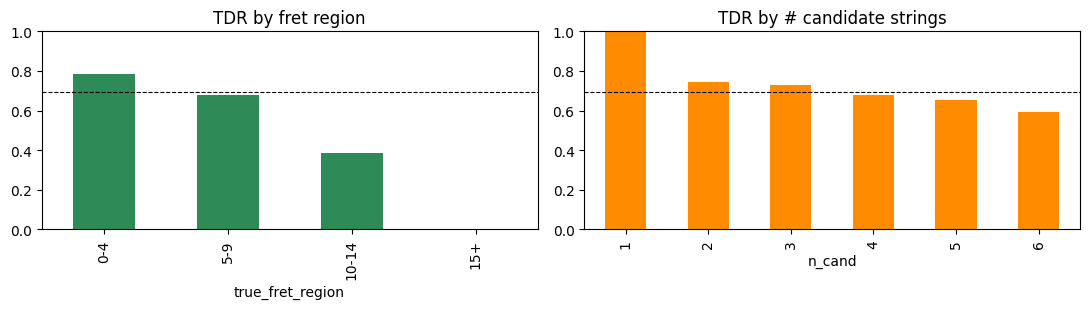

In [6]:
def n_candidate_strings(midi):
    return sum(1 for o in OPEN_STRING_MIDI if 0 <= midi - o <= MAX_FRET)

d['true_fret_region'] = pd.cut(d['true_fret'], [-1,4,9,14,24], labels=['0-4','5-9','10-14','15+'])
reg = d.groupby('true_fret_region', observed=True).agg(n=('exact_tab_correct','size'), TDR=('exact_tab_correct','mean'))
print("TDR by true fret region:")
display(reg.round(4))

d['n_cand'] = d['midi'].apply(n_candidate_strings)
amb = d.groupby('n_cand').agg(n=('exact_tab_correct','size'), TDR=('exact_tab_correct','mean'))
print("\nTDR by # candidate strings for the pitch (ambiguity):")
display(amb.round(4))
print("Accuracy should fall as candidate strings rise — that's the disambiguation the prior is meant to solve.")

fig,ax=plt.subplots(1,2,figsize=(11,3.2))
reg['TDR'].plot(kind='bar',ax=ax[0],color='seagreen'); ax[0].set_title('TDR by fret region'); ax[0].set_ylim(0,1); ax[0].axhline(d['exact_tab_correct'].mean(),ls='--',c='k',lw=0.8)
amb['TDR'].plot(kind='bar',ax=ax[1],color='darkorange'); ax[1].set_title('TDR by # candidate strings'); ax[1].set_ylim(0,1); ax[1].axhline(d['exact_tab_correct'].mean(),ls='--',c='k',lw=0.8)
plt.tight_layout(); plt.show()

## 7. Worst recordings — is it broad or a few pathological files?

In [7]:
rec = (d.groupby('recording')
         .agg(n=('exact_tab_correct','size'), TDR=('exact_tab_correct','mean'),
              segment=('segment','first'))
         .sort_values('TDR'))
print("10 worst recordings by TDR:")
display(rec.head(10).round(4))
print("\n10 best:")
display(rec.tail(10).round(4))
print(f"\nTDR spread across recordings: min={rec['TDR'].min():.3f}  median={rec['TDR'].median():.3f}  max={rec['TDR'].max():.3f}")
print("Wide spread + clustered-bad files => targeted failure (e.g. chord-context). Uniform => systematic prior bias.")

10 worst recordings by TDR:


,n,TDR,segment
recording,,,
04_Jazz2-187-F#_comp,99,0.1919,comp
05_BN1-147-Gb_solo,25,0.2000,solo
04_Rock1-130-A_comp,158,0.2342,comp
05_BN3-154-E_comp,152,0.2829,comp
04_Rock3-148-C_solo,62,0.2903,solo
01_BN3-154-E_solo,98,0.3163,solo
00_Rock3-117-Bb_solo,145,0.3172,solo
02_BN1-147-Gb_comp,144,0.3194,comp
05_BN1-129-Eb_solo,43,0.3721,solo



10 best:


,n,TDR,segment
recording,,,
00_Rock2-142-D_comp,319,0.8276,comp
05_Rock3-117-Bb_comp,308,0.8409,comp
05_Rock2-85-F_solo,115,0.8435,solo
03_Rock1-130-A_solo,53,0.8491,solo
01_BN1-129-Eb_comp,88,0.8523,comp
02_BN2-131-B_solo,59,0.8644,solo
04_SS1-68-E_comp,445,0.8742,comp
01_Jazz1-130-D_comp,98,0.8980,comp
01_SS1-100-C#_comp,274,0.9854,comp



TDR spread across recordings: min=0.192  median=0.699  max=0.992
Wide spread + clustered-bad files => targeted failure (e.g. chord-context). Uniform => systematic prior bias.


## 8. Verdict — which lever does the evidence point to?

Auto-summarizes the three decisive cuts into a recommendation.

In [8]:
adj_share = (wrong['abs_d_string']==1).mean()
far_share = (wrong['abs_d_string']>=2).mean()
solo_tdr = seg_df.set_index('segment').loc['solo','TDR'] if 'solo' in seg_df['segment'].values else np.nan
comp_tdr = seg_df.set_index('segment').loc['comp','TDR'] if 'comp' in seg_df['segment'].values else np.nan
amb_gap = amb['TDR'].iloc[0] - amb['TDR'].iloc[-1] if len(amb)>1 else np.nan

print("="*64)
print(f"METHOD={METHOD}   overall TDR={d['exact_tab_correct'].mean():.3f}")
print("="*64)
print(f"Adjacent-string errors:  {adj_share:.0%}   | far-off (>=2): {far_share:.0%}")
print(f"Solo TDR:  {solo_tdr:.3f}   Comp TDR:  {comp_tdr:.3f}   (gap {solo_tdr-comp_tdr:+.3f})")
print(f"Ambiguity gap (fewest vs most candidate strings): {amb_gap:+.3f}")
print("-"*64)
print("READING:")
if adj_share >= 0.8:
    print(f"- {adj_share:.0%} of errors are ONE string off => mostly valid alternate fingerings.")
    print("  Lever: the POSITION PRIOR (match human string choice). Biggest realistic win,")
    print("  but capped — some choice is genuinely player-specific/arbitrary.")
else:
    print(f"- Only {adj_share:.0%} adjacent; {far_share:.0%} are >=2 strings off => real candidate-scoring errors.")
    print("  Lever: candidate generation / transition costs (the Viterbi scoring).")
if not np.isnan(solo_tdr) and not np.isnan(comp_tdr):
    if comp_tdr < solo_tdr - 0.03:
        print("- Comp lags solo => CHORD VOICING path is the weak link (good news: caged_voiced targets this).")
    elif solo_tdr < comp_tdr - 0.03:
        print("- Solo lags comp => SOLO CHORD-CONTEXT collapse is dragging assignment; fix key/chord detect on solos.")
    else:
        print("- Solo ~ comp => error is context-independent; it's in the core position model.")
print("="*64)

METHOD=caged_voiced   overall TDR=0.692
Adjacent-string errors:  96%   | far-off (>=2): 4%
Solo TDR:  0.607   Comp TDR:  0.731   (gap -0.124)
Ambiguity gap (fewest vs most candidate strings): +0.410
----------------------------------------------------------------
READING:
- 96% of errors are ONE string off => mostly valid alternate fingerings.
  Lever: the POSITION PRIOR (match human string choice). Biggest realistic win,
  but capped — some choice is genuinely player-specific/arbitrary.
- Solo lags comp => SOLO CHORD-CONTEXT collapse is dragging assignment; fix key/chord detect on solos.
